In [ ]:
# notebooks/01_earthquake_exploration.py
"""
Simple exploration of California earthquake data
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

# setup paths
try:
    # running as a script
    project_root = Path(__file__).resolve().parents[1]
except NameError:
    # running in Jupyter/VSCode interactive
    project_root = Path.cwd()
    # if we're in the notebooks directory, go up one level
    if project_root.name == 'notebooks':
        project_root = project_root.parent

sys.path.insert(0, str(project_root))

from src.collectors.usgs_earthquake import USGSEarthquakeCollector
from src.utils.helpers import setup_logging, load_config

In [5]:
# configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# define directories
data_dir = project_root / "data"
raw_dir = data_dir / "raw" / "earthquakes"

# create directories
raw_dir.mkdir(parents=True, exist_ok=True)

EARTHQUAKE DATA EXPLORATION
Project root: c:\Users\woodn\OneDrive\Desktop\MAPOU_LAB_CAPSTONE\earthquake-flood-alert

Loading data from california_training_data.csv...
Loaded 13,284 earthquakes
Date range: 2015-01-01 08:43:07.260000+00:00 to 2023-12-31 20:28:15.190000+00:00


STATISTICS

Magnitude:
count    13284.000000
mean         2.932843
std          0.438978
min          2.500000
25%          2.610000
50%          2.800000
75%          3.100000
max          7.100000
Name: mag, dtype: float64

Depth (km):
count    13284.000000
mean         7.394939
std          5.806851
min         -2.300000
25%          3.537500
50%          6.440000
75%          9.460000
max         74.160000
Name: depth, dtype: float64
Magnitude >= 5.0: 36 (0.3%)
Magnitude >= 6.0: 6 (0.0%)

Missing values:
time                106
latitude              0
longitude             0
depth                 0
mag                   0
magType               1
nst                  96
gap                   2
dmin              

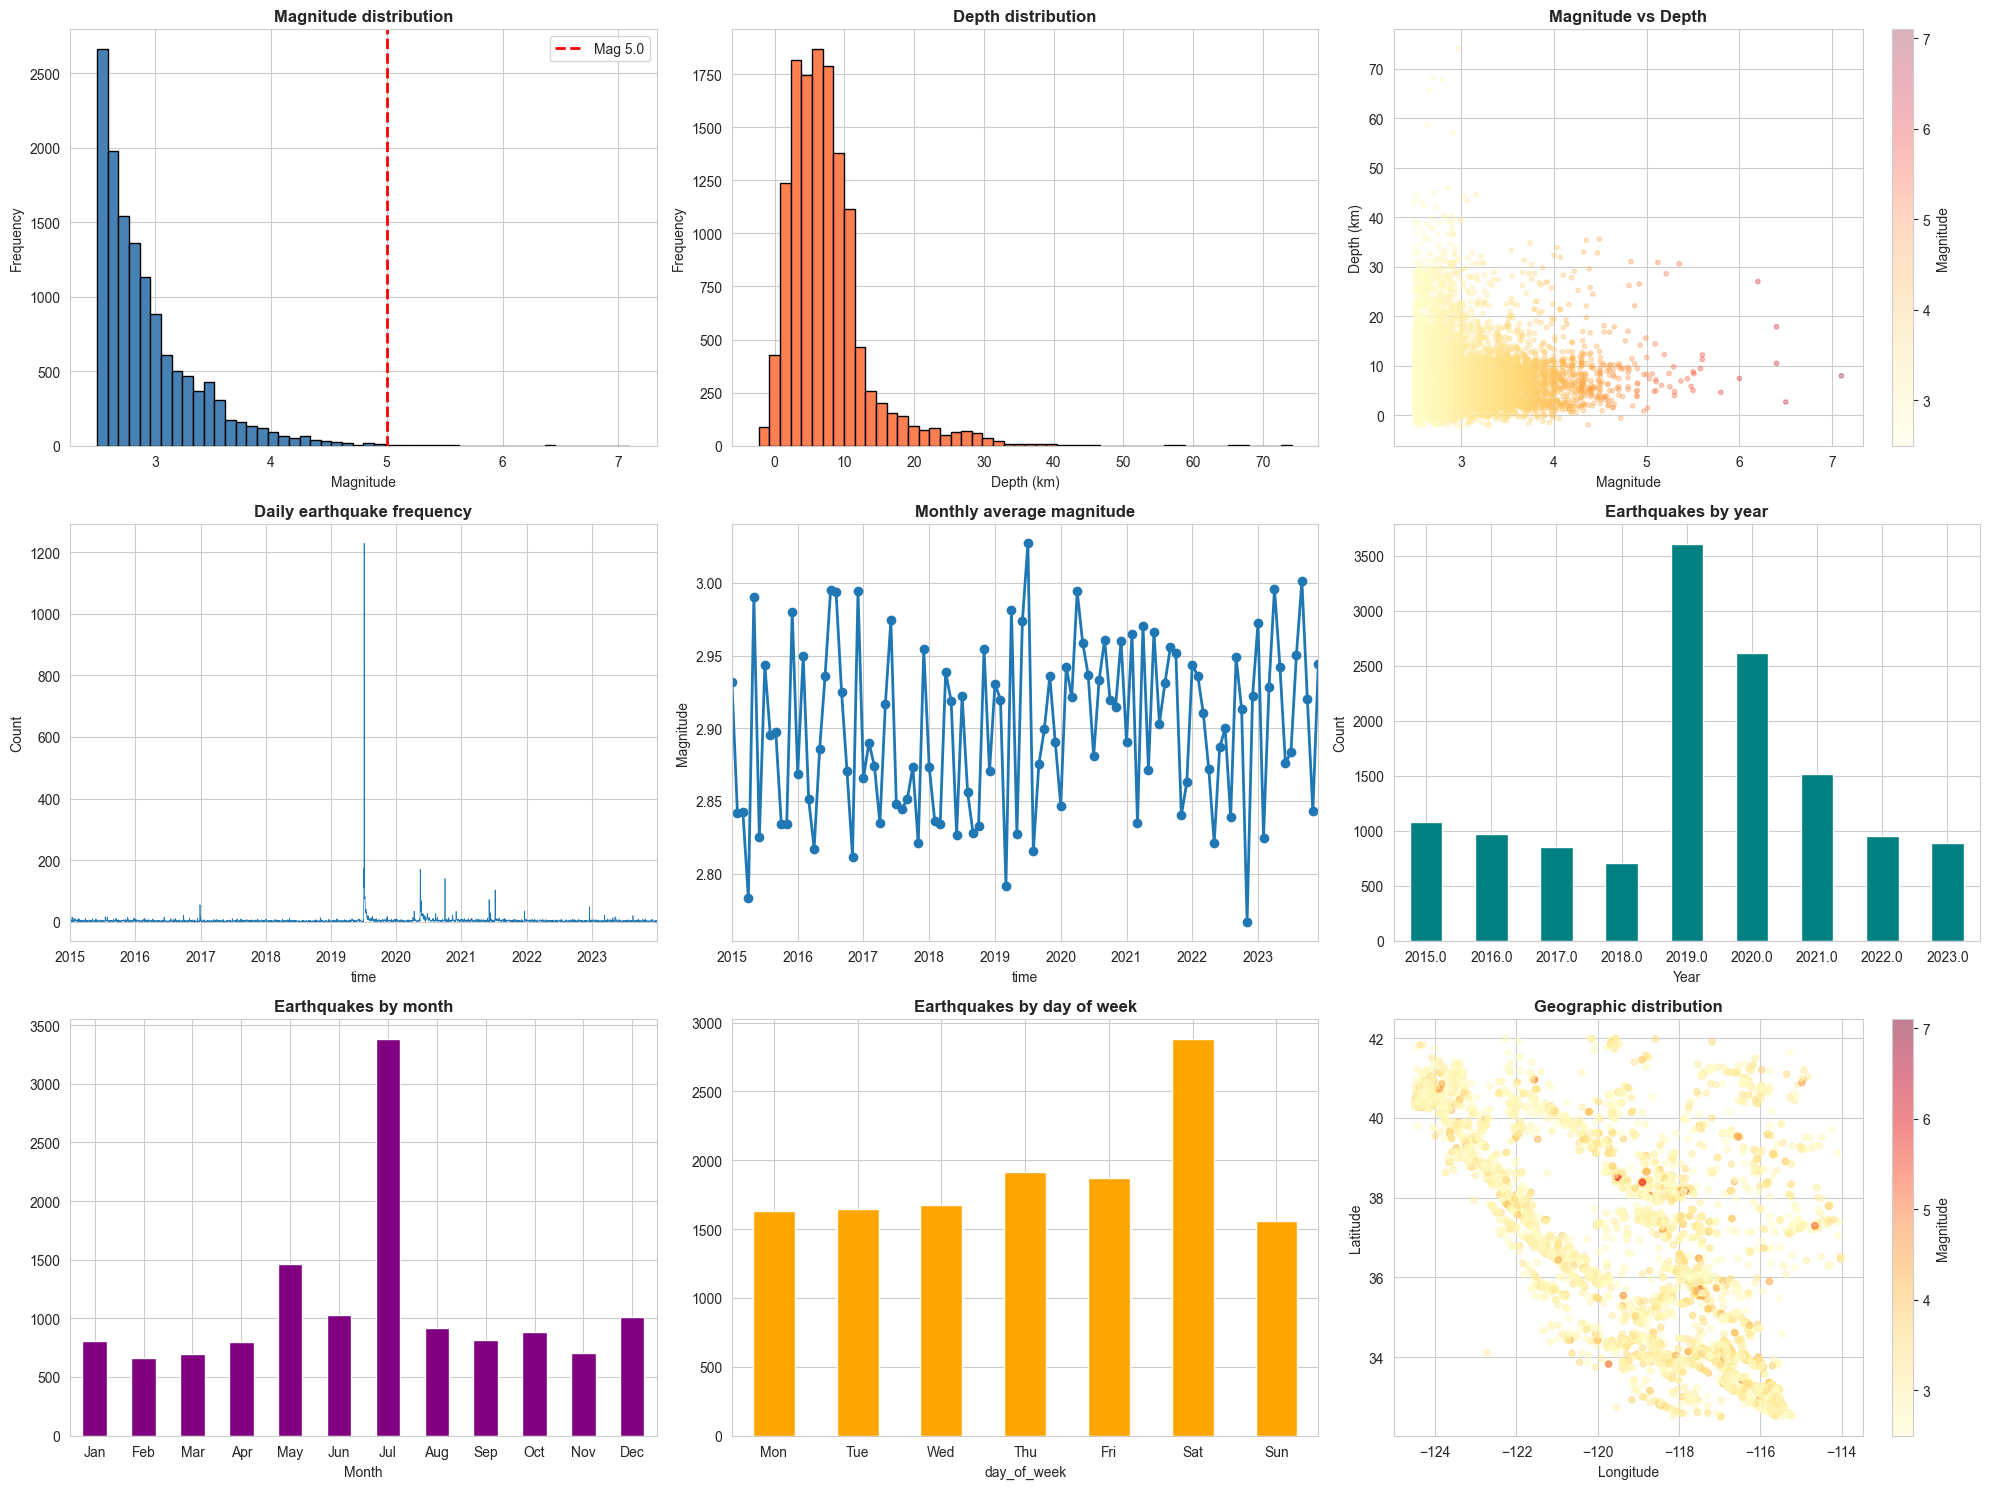

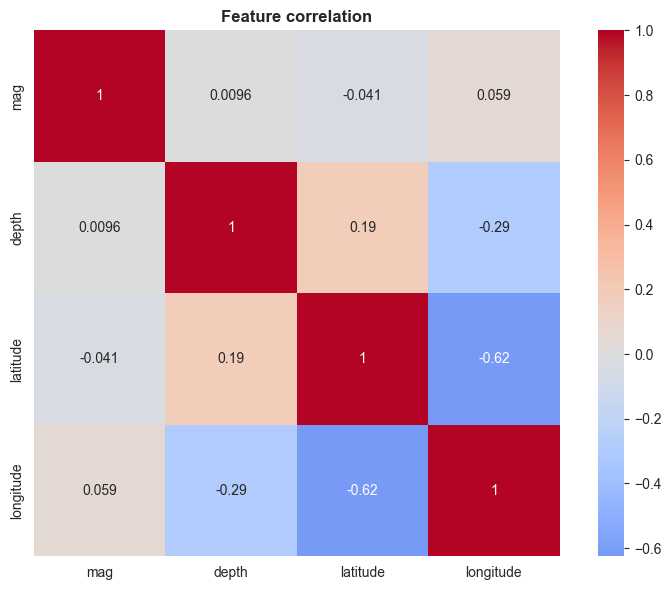

In [11]:

def explore_earthquake_data():
    """Explore earthquake data with visualizations"""
    
    print("EARTHQUAKE DATA EXPLORATION")
    print(f"Project root: {project_root}")
    
    # load or fecth data
    training_file = raw_dir / 'california_training_data.csv'
    
    if training_file.exists():
        print(f"\nLoading data from {training_file.name}...")
        df = pd.read_csv(training_file)
        df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
    else:
        print("\nFetching data from USGS...")
        setup_logging()
        config = load_config()
        
        collector = USGSEarthquakeCollector()
        ca_config = config['earthquake']['regions']['california']
        
        df = collector.fetch_by_region(
            min_lat=ca_config['min_lat'],
            max_lat=ca_config['max_lat'],
            min_lon=ca_config['min_lon'],
            max_lon=ca_config['max_lon'],
            start_date=config['earthquake']['training']['start_date'],
            end_date=config['earthquake']['training']['end_date'],
            min_magnitude=config['earthquake']['min_magnitude']
        )
        
        if df is None:
            print("Failed to fetch data!")
            return None
        
        collector.save_data(df, "california_training_data.csv")
    
    print(f"Loaded {len(df):,} earthquakes")
    print(f"Date range: {df['time'].min()} to {df['time'].max()}")
    
    # basic statistics
    print("\n")
    print("STATISTICS")
    print(f"\nMagnitude:\n{df['mag'].describe()}")
    print(f"\nDepth (km):\n{df['depth'].describe()}")
    
    for mag in [5.0, 6.0]:
        count = len(df[df['mag'] >= mag])
        print(f"Magnitude >= {mag}: {count:,} ({count/len(df)*100:.1f}%)")
    
    # data quality
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"Duplicates: {df.duplicated().sum()}")
    
    # time features
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df['day_of_week'] = df['time'].dt.dayofweek
    
    # create visualizations
    fig = plt.figure(figsize=(20, 15))
    
    # 1. magnitude distribution
    plt.subplot(3, 3, 1)
    df['mag'].hist(bins=50, edgecolor='black', color='steelblue')
    plt.axvline(5.0, color='red', linestyle='--', linewidth=2, label='Mag 5.0')
    plt.title('Magnitude distribution', fontweight='bold')
    plt.xlabel('Magnitude')
    plt.ylabel('Frequency')
    plt.legend()
    
    # 2. depth distribution
    plt.subplot(3, 3, 2)
    df['depth'].hist(bins=50, edgecolor='black', color='coral')
    plt.title('Depth distribution', fontweight='bold')
    plt.xlabel('Depth (km)')
    plt.ylabel('Frequency')
    
    # 3. magnitude vs depth
    plt.subplot(3, 3, 3)
    plt.scatter(df['mag'], df['depth'], alpha=0.3, s=10, c=df['mag'], cmap='YlOrRd')
    plt.colorbar(label='Magnitude')
    plt.title('Magnitude vs Depth', fontweight='bold')
    plt.xlabel('Magnitude')
    plt.ylabel('Depth (km)')
    
    # 4. daily frequency
    plt.subplot(3, 3, 4)
    df.set_index('time').resample('D').size().plot(linewidth=0.5)
    plt.title('Daily earthquake frequency', fontweight='bold')
    plt.ylabel('Count')
    
    # 5. monthly average magnitude
    plt.subplot(3, 3, 5)
    df.set_index('time').resample('M')['mag'].mean().plot(linewidth=2, marker='o')
    plt.title('Monthly average magnitude', fontweight='bold')
    plt.ylabel('Magnitude')
    
    # 6. yearly counts
    plt.subplot(3, 3, 6)
    df.groupby('year').size().plot(kind='bar', color='teal')
    plt.title('Earthquakes by year', fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    
    # 7. monthly distribution
    plt.subplot(3, 3, 7)
    df.groupby('month').size().plot(kind='bar', color='purple')
    plt.title('Earthquakes by month', fontweight='bold')
    plt.xlabel('Month')
    plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
    
    # 8. day of week
    plt.subplot(3, 3, 8)
    df.groupby('day_of_week').size().plot(kind='bar', color='orange')
    plt.title('Earthquakes by day of week', fontweight='bold')
    plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
    
    # 9. geographic map
    plt.subplot(3, 3, 9)
    plt.scatter(df['longitude'], df['latitude'], c=df['mag'], 
                cmap='YlOrRd', alpha=0.5, s=20)
    plt.colorbar(label='Magnitude')
    plt.title('Geographic distribution', fontweight='bold')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    
    plt.tight_layout()
    viz_path = data_dir / 'earthquake_exploration.png'
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved visualization: {viz_path}")
    
    # top earthquakes
    print("\n")
    print("TOP 10 EARTHQUAKES")
    top = df.nlargest(10, 'mag')[['time', 'mag', 'depth', 'place']]
    print(top.to_string())
    
    # correlation
    print("\n")
    print("CORRELATIONS")
    corr = df[['mag', 'depth', 'latitude', 'longitude']].corr()
    print(corr)
    
    # correlation heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
    plt.title('Feature correlation', fontweight='bold')
    plt.tight_layout()
    corr_path = data_dir / 'earthquake_correlation.png'
    plt.savefig(corr_path, dpi=300, bbox_inches='tight')
    print(f"Saved correlation: {corr_path}")
    
    # save summary
    summary = {
        'total_earthquakes': int(len(df)),
        'date_range': f"{df['time'].min()} to {df['time'].max()}",
        'magnitude_mean': float(df['mag'].mean()),
        'magnitude_max': float(df['mag'].max()),
        'significant_count': int(len(df[df['mag'] >= 5.0]))
    }
    
    summary_file = data_dir / 'processed' / 'earthquake_summary.json'
    summary_file.parent.mkdir(exist_ok=True)
    with open(summary_file, 'w') as f:
        json.dump(summary, f, indent=4)
    print(f"Saved summary: {summary_file}")
    
    print("\n")
    print("EXPLORATION COMPLETE!")
    
    return df

if __name__ == "__main__":
    df = explore_earthquake_data()
    if df is not None:
        plt.show()